In [20]:
import torch 
import re
import os
import copy
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path 
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from sklearn.preprocessing import StandardScaler
import joblib
from torch.utils.data import Dataset, DataLoader, random_split
import argparse
import torch.optim as optim
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(torch.cuda.is_available())

True


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
df_csv=pd.read_csv('df_final_nv.csv')

In [5]:
df_csv.head()

,serialno,no,weight,length,age,sex,stage,liverweight,gonadweight,spawningage,spawningzones,readability,otolithedge,otolithtype_2,otolithtype_4,otolithtype_5
0,70029,1,-0.554135,-0.282389,6.0,2,1,-0.642656,-0.611509,-0.191298,-0.536424,1.365130,4,0,0,1
1,70029,2,-0.905812,-1.108129,3.0,1,1,-0.751148,-0.610037,-1.528887,-0.536424,-0.438642,4,0,0,1
2,70029,3,-0.856653,-0.911525,4.0,2,1,-0.757344,-0.611509,-1.083024,-0.536424,-0.438642,4,0,0,1
3,70029,4,-1.054802,-2.248438,1.0,0,1,-0.612892,-0.336299,0.214507,-0.536424,-0.438642,4,0,0,1
4,70029,6,-1.009172,-1.658623,3.0,1,1,-0.702568,-0.336299,-1.528887,-0.536424,-0.438642,4,0,0,1


### EfficientNet

### Jointure CSV + IMAGES

In [6]:
root = Path('premiere_approche/EfficientNet')
otolith_dirs = list(root.rglob("Nr*_age*"))

In [7]:
def extract_nr_from_folder(folder_name):
    match = re.search(r'Nr(\d+)_age*', folder_name)
    return int(match.group(1)) if match else None

In [8]:
def path_images(otolith_directory):
    images = list(otolith_directory.glob("*"))
    images = [f for f in images if f.suffix.lower() in {".png"}]
 
    images_sorted = sorted(images, key=lambda x: x.name)
    path_0   = str(images_sorted[0].resolve())
    path_180 = str(images_sorted[1].resolve())
 
    return path_0, path_180

In [9]:
records = []
for otlt in otolith_dirs:
    serial = int(otlt.parent.name)
    folder = otlt.name
    try:
        age_from_folder = extract_nr_from_folder(folder)
    except:
        continue

    img_0deg, img_180deg = path_images(otlt)
    records.append({
        'serial': serial,
        'folder': folder,
        'no_folder': age_from_folder,
        'img_path_0' : img_0deg,
        'img_path_180': img_180deg
    })

In [10]:
df_records = pd.DataFrame(records)

In [11]:
df_merged = df_csv.merge(
    df_records,
    left_on=['serialno', 'no'],
    right_on=['serial', 'no_folder'],
    how='inner'
)

In [12]:
print(f"Total après jointure : {len(df_merged)} dossiers")
print(f"Distribution des âges :\n{df_merged['age'].value_counts().sort_index()}")

Total après jointure : 884 dossiers
Distribution des âges :
age
1.0      31
2.0      40
3.0      53
4.0      74
5.0      77
6.0     119
7.0     128
8.0     114
9.0      84
10.0     47
11.0     44
12.0     47
13.0     12
14.0      9
15.0      3
16.0      2
Name: count, dtype: int64


In [13]:
df_merged.head()

,serialno,no,weight,length,age,sex,stage,liverweight,gonadweight,spawningage,...,readability,otolithedge,otolithtype_2,otolithtype_4,otolithtype_5,serial,folder,no_folder,img_path_0,img_path_180
0,70029,1,-0.554135,-0.282389,6.0,2,1,-0.642656,-0.611509,-0.191298,...,1.365130,4,0,0,1,70029,Nr01_age06,1,C:\Users\LENOVO\otolith\premiere_approche\Effi...,C:\Users\LENOVO\otolith\premiere_approche\Effi...
1,70029,2,-0.905812,-1.108129,3.0,1,1,-0.751148,-0.610037,-1.528887,...,-0.438642,4,0,0,1,70029,Nr02_age03,2,C:\Users\LENOVO\otolith\premiere_approche\Effi...,C:\Users\LENOVO\otolith\premiere_approche\Effi...
2,70029,3,-0.856653,-0.911525,4.0,2,1,-0.757344,-0.611509,-1.083024,...,-0.438642,4,0,0,1,70029,Nr03_age04,3,C:\Users\LENOVO\otolith\premiere_approche\Effi...,C:\Users\LENOVO\otolith\premiere_approche\Effi...
3,70029,4,-1.054802,-2.248438,1.0,0,1,-0.612892,-0.336299,0.214507,...,-0.438642,4,0,0,1,70029,Nr04_age01,4,C:\Users\LENOVO\otolith\premiere_approche\Effi...,C:\Users\LENOVO\otolith\premiere_approche\Effi...
4,70029,6,-1.009172,-1.658623,3.0,1,1,-0.702568,-0.336299,-1.528887,...,-0.438642,4,0,0,1,70029,Nr06_age03,6,C:\Users\LENOVO\otolith\premiere_approche\Effi...,C:\Users\LENOVO\otolith\premiere_approche\Effi...


In [14]:
df_merged.to_csv('df_merged_efficientnet.csv', index=False)
print(f"Saved: {'df_merged_efficientnet.csv'}  ({len(df_merged)} rows, {df_merged.shape[1]} columns)")
print(f"Columns: {list(df_merged.columns)}")

Saved: df_merged_efficientnet.csv  (884 rows, 21 columns)
Columns: ['serialno', 'no', 'weight', 'length', 'age', 'sex', 'stage', 'liverweight', 'gonadweight', 'spawningage', 'spawningzones', 'readability', 'otolithedge', 'otolithtype_2', 'otolithtype_4', 'otolithtype_5', 'serial', 'folder', 'no_folder', 'img_path_0', 'img_path_180']


## Training 

In [15]:
class MultiModalRegressor(nn.Module):
    def __init__(self, n_tab, hidden=256, dropout=0.3):
        super().__init__()
        base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        old = base.features[0][0]
        new_conv = nn.Conv2d(6, old.out_channels, kernel_size=old.kernel_size,
                             stride=old.stride, padding=old.padding, bias=False)
        with torch.no_grad():
            new_conv.weight.data = torch.cat([old.weight.data, old.weight.data], dim=1) / 2.0
        base.features[0][0] = new_conv
        feat_dim = base.classifier[1].in_features
        base.classifier = nn.Identity()
        self.backbone = base
        self.tab_mlp = nn.Sequential(
            nn.Linear(n_tab, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),   nn.BatchNorm1d(64),  nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.Linear(feat_dim + 64, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, img, tab):
        return self.head(torch.cat([self.backbone(img),self.tab_mlp(tab)], dim=1)).squeeze(1)

In [27]:
CSV_PATH     = "df_merged_efficientnet.csv"
TARGET_COL   = "age"
IMG_COL_0    = "img_path_0"
IMG_COL_180  = "img_path_180"
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 50
LR           = 1e-4
VAL_FRAC     = 0.15
TEST_FRAC    = 0.15
SEED         = 42
OUTPUT_DIR   = Path("outputs/efficientnet")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EXCLUDE_COLS = {IMG_COL_0, IMG_COL_180, TARGET_COL, "serial", "folder", "no_folder","serialno","no", "spawningage", "readability", "otolithedge"}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [28]:
class OtolithDataset(Dataset):
    IMG_MEAN = [0.485, 0.456, 0.406]
    IMG_STD  = [0.229, 0.224, 0.225]

    def __init__(self, df, tab_cols, augment=False, scaler=None):
        self.df       = df.reset_index(drop=True)
        self.tab_cols = tab_cols
        tab_data = self.df[tab_cols].values.astype(np.float32)
        if scaler is None:
            self.scaler = StandardScaler()
            self.tab_scaled = self.scaler.fit_transform(tab_data)
        else:
            self.scaler = scaler
            self.tab_scaled = self.scaler.transform(tab_data)

        base = [T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(),
                T.Normalize(self.IMG_MEAN, self.IMG_STD)]
        aug  = [T.Resize((IMG_SIZE, IMG_SIZE)),
                T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
                T.ColorJitter(brightness=0.2, contrast=0.2),
                T.ToTensor(), T.Normalize(self.IMG_MEAN, self.IMG_STD)]
        self.tf = T.Compose(aug if augment else base)

    def __len__(self): return len(self.df)

    def _load(self, path):
        return self.tf(Image.open(path).convert("RGB"))

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = torch.cat([self._load(row[IMG_COL_0]),
                          self._load(row[IMG_COL_180])], dim=0)
        tab  = torch.tensor(self.tab_scaled[idx], dtype=torch.float32)
        age  = torch.tensor(float(row[TARGET_COL]), dtype=torch.float32)
        return img, tab, age

In [29]:
torch.manual_seed(SEED); np.random.seed(SEED)

df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=[IMG_COL_0, IMG_COL_180, TARGET_COL])
tab_cols = [c for c in df.columns
            if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(df[c])]
df[tab_cols] = df[tab_cols].fillna(df[tab_cols].median())

print(f"Rows: {len(df)} | Tabular features ({len(tab_cols)}): {tab_cols}")

df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
n = len(df)
n_test  = int(n * TEST_FRAC)
n_val   = int(n * VAL_FRAC)
df_train = df.iloc[:n - n_val - n_test]
df_val   = df.iloc[n - n_val - n_test : n - n_test]
df_test  = df.iloc[n - n_test:]
print(f"Train={len(df_train)} | Val={len(df_val)} | Test={len(df_test)}")

ds_train = OtolithDataset(df_train, tab_cols, augment=True)
scaler   = ds_train.scaler
ds_val   = OtolithDataset(df_val,   tab_cols, augment=False, scaler=scaler)
ds_test  = OtolithDataset(df_test,  tab_cols, augment=False, scaler=scaler)

kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=False)
train_dl = DataLoader(ds_train, shuffle=True,  **kw)
val_dl   = DataLoader(ds_val,   shuffle=False, **kw)
test_dl  = DataLoader(ds_test,  shuffle=False, **kw)

joblib.dump(scaler, OUTPUT_DIR / "scaler.pkl")

Rows: 884 | Tabular features (10): ['weight', 'length', 'sex', 'stage', 'liverweight', 'gonadweight', 'spawningzones', 'otolithtype_2', 'otolithtype_4', 'otolithtype_5']
Train=620 | Val=132 | Test=132


['outputs\\efficientnet\\scaler.pkl']

In [30]:
model     = MultiModalRegressor(n_tab=len(tab_cols)).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss": [], "val_mae": [], "val_rmse": [], "val_r2": []}
best_mae, best_weights = float("inf"), None

for epoch in tqdm(range(1, EPOCHS + 1)):
    model.train()
    losses = []
    for img, tab, age in train_dl:
        img, tab, age = img.to(device), tab.to(device), age.to(device)
        optimizer.zero_grad()
        loss = criterion(model(img, tab), age)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    scheduler.step()

    # ── validate
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for img, tab, age in val_dl:
            preds.extend(model(img.to(device), tab.to(device)).cpu().numpy())
            targets.extend(age.numpy())
    preds, targets = np.array(preds), np.array(targets)
    mae  = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    r2   = r2_score(targets, preds)

    history["train_loss"].append(np.mean(losses))
    history["val_mae"].append(mae)
    history["val_rmse"].append(rmse)
    history["val_r2"].append(r2)

    if mae < best_mae:
        best_mae = mae
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, OUTPUT_DIR / "efficientnet_best.pth")

    if epoch % 5 == 0 or epoch == 1:
        tqdm.write(f"Epoch {epoch:3d}/{EPOCHS} | loss={np.mean(losses):.4f} | " f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

print(f"\nBest Val MAE: {best_mae:.3f}")
model.load_state_dict(best_weights)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch   1/50 | loss=56.1697 | MAE=6.809 | RMSE=7.368 | R²=-5.270
Epoch   5/50 | loss=26.4187 | MAE=4.506 | RMSE=4.949 | R²=-1.830
Epoch  10/50 | loss=6.6377 | MAE=2.217 | RMSE=2.748 | R²=0.128
Epoch  15/50 | loss=2.6455 | MAE=1.477 | RMSE=2.048 | R²=0.516
Epoch  20/50 | loss=2.0399 | MAE=1.103 | RMSE=1.628 | R²=0.694
Epoch  25/50 | loss=1.7116 | MAE=1.043 | RMSE=1.537 | R²=0.727
Epoch  30/50 | loss=1.5455 | MAE=0.994 | RMSE=1.453 | R²=0.756
Epoch  35/50 | loss=1.1735 | MAE=0.953 | RMSE=1.386 | R²=0.778
Epoch  40/50 | loss=1.2621 | MAE=0.997 | RMSE=1.427 | R²=0.765
Epoch  45/50 | loss=1.1814 | MAE=0.957 | RMSE=1.378 | R²=0.781
Epoch  50/50 | loss=1.2761 | MAE=0.947 | RMSE=1.360 | R²=0.786

Best Val MAE: 0.904


<All keys matched successfully>

TEST  MAE : 0.720 years
TEST  RMSE: 0.976 years
TEST  R²  : 0.8807


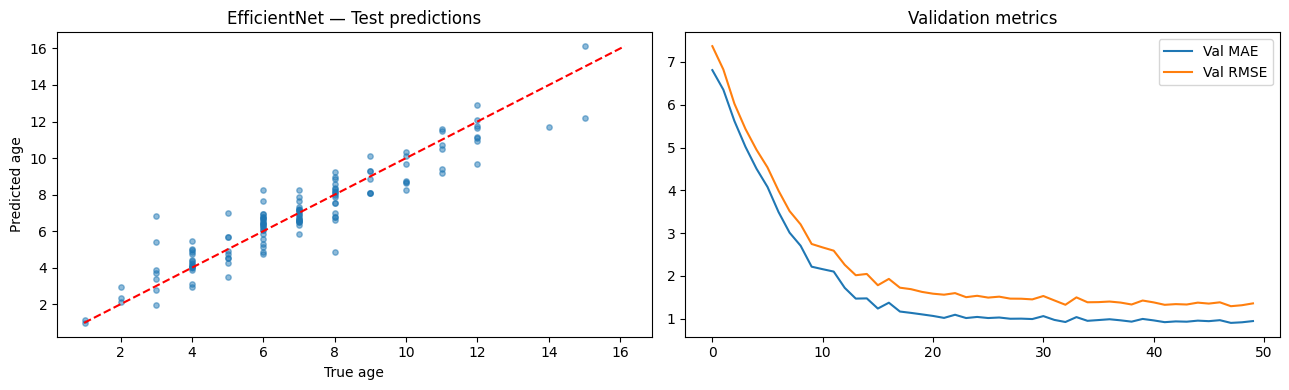

In [31]:
model.eval()
preds, targets = [], []
with torch.no_grad():
    for img, tab, age in test_dl:
        preds.extend(model(img.to(device), tab.to(device)).cpu().numpy())
        targets.extend(age.numpy())
preds, targets = np.array(preds), np.array(targets)

print(f"TEST  MAE : {mean_absolute_error(targets, preds):.3f} years")
print(f"TEST  RMSE: {np.sqrt(mean_squared_error(targets, preds)):.3f} years")
print(f"TEST  R²  : {r2_score(targets, preds):.4f}")

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
lo, hi = min(targets.min(), preds.min()), max(targets.max(), preds.max())
axes[0].scatter(targets, preds, alpha=0.5, s=15)
axes[0].plot([lo, hi], [lo, hi], "r--")
axes[0].set_xlabel("True age"); axes[0].set_ylabel("Predicted age")
axes[0].set_title("EfficientNet — Test predictions")

# Learning curves
axes[1].plot(history["val_mae"], label="Val MAE")
axes[1].plot(history["val_rmse"], label="Val RMSE")
axes[1].set_title("Validation metrics"); axes[1].legend()
plt.tight_layout(); plt.show()

pd.DataFrame({"true_age": targets, "pred_age": preds}).to_csv(
    OUTPUT_DIR / "test_predictions.csv", index=False)

In [32]:
LR_FINETUNE = 1e-5
EPOCHS_FINETUNE = 30

for param in model.backbone.parameters():
    param.requires_grad = True

optimizer_ft = optim.AdamW([
    {"params": model.backbone.parameters(), "lr": LR_FINETUNE},
    {"params": model.tab_mlp.parameters(),  "lr": LR_FINETUNE * 10},
    {"params": model.head.parameters(),     "lr": LR_FINETUNE * 10},
], weight_decay=1e-4)

scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=EPOCHS_FINETUNE)
criterion = nn.MSELoss()

history_ft = {"train_loss": [], "val_mae": [], "val_rmse": [], "val_r2": []}
best_mae_ft = best_mae
best_weights_ft = copy.deepcopy(model.state_dict())

In [33]:
for epoch in tqdm(range(1, EPOCHS_FINETUNE + 1)):
    model.train()
    losses = []
    for img, tab, age in train_dl:
        img, tab, age = img.to(device), tab.to(device), age.to(device)
        optimizer_ft.zero_grad()
        loss = criterion(model(img, tab), age)
        loss.backward()
        optimizer_ft.step()
        losses.append(loss.item())
    scheduler_ft.step()

    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for img, tab, age in val_dl:
            preds.extend(model(img.to(device), tab.to(device)).cpu().numpy())
            targets.extend(age.numpy())
    preds, targets = np.array(preds), np.array(targets)
    mae  = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    r2   = r2_score(targets, preds)

    history_ft["train_loss"].append(np.mean(losses))
    history_ft["val_mae"].append(mae)
    history_ft["val_rmse"].append(rmse)
    history_ft["val_r2"].append(r2)

    if mae < best_mae_ft:
        best_mae_ft = mae
        best_weights_ft = copy.deepcopy(model.state_dict())
        torch.save(best_weights_ft, OUTPUT_DIR / "efficientnet_finetuned.pth")

    if epoch % 5 == 0 or epoch == 1:
        tqdm.write(f"FT Epoch {epoch:3d}/{EPOCHS_FINETUNE} | loss={np.mean(losses):.4f} | "
                   f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

print(f"\nBest Fine-tune Val MAE: {best_mae_ft:.3f}  (before: {best_mae:.3f})")
model.load_state_dict(best_weights_ft)

  0%|          | 0/30 [00:00<?, ?it/s]

FT Epoch   1/30 | loss=1.3685 | MAE=1.021 | RMSE=1.453 | R²=0.756
FT Epoch   5/30 | loss=1.4268 | MAE=0.982 | RMSE=1.393 | R²=0.776
FT Epoch  10/30 | loss=1.0563 | MAE=0.909 | RMSE=1.272 | R²=0.813
FT Epoch  15/30 | loss=1.0776 | MAE=0.909 | RMSE=1.267 | R²=0.814
FT Epoch  20/30 | loss=1.0041 | MAE=0.840 | RMSE=1.160 | R²=0.844
FT Epoch  25/30 | loss=0.9267 | MAE=0.865 | RMSE=1.195 | R²=0.835
FT Epoch  30/30 | loss=1.0913 | MAE=0.862 | RMSE=1.191 | R²=0.836

Best Fine-tune Val MAE: 0.829  (before: 0.904)


<All keys matched successfully>

In [34]:
model.eval()
preds, targets = [], []
with torch.no_grad():
    for img, tab, age in test_dl:
        preds.extend(model(img.to(device), tab.to(device)).cpu().numpy())
        targets.extend(age.numpy())
preds, targets = np.array(preds), np.array(targets)
print("── EfficientNet Fine-tuned ──")
print(f"TEST  MAE : {mean_absolute_error(targets, preds):.3f} years")
print(f"TEST  RMSE: {np.sqrt(mean_squared_error(targets, preds)):.3f} years")
print(f"TEST  R²  : {r2_score(targets, preds):.4f}")

── EfficientNet Fine-tuned ──
TEST  MAE : 0.677 years
TEST  RMSE: 0.902 years
TEST  R²  : 0.8981
